Soal Nomor 1 Essay - Time Series 

In [4]:
import pandas as pd

# Load the police dataset
police_data = pd.read_csv('police.csv')

# Display first and last rows
display (data.head(91736))

,state,stop_date,stop_time,county_name,driver_gender,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop,district
0,RI,2005-01-04,12:55,NaN,M,White,Equipment/Inspection Violation,Equipment,False,NaN,Citation,False,0-15 Min,False,Zone X4
1,RI,2005-01-23,23:15,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone K3
2,RI,2005-02-17,04:15,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone X4
3,RI,2005-02-20,17:15,NaN,M,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False,Zone X1
4,RI,2005-02-24,01:20,NaN,F,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone X3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91731,RI,2015-12-31,13:23,NaN,M,White,Speeding,Speeding,False,NaN,N/D,False,16-30 Min,False,Zone X1
91732,RI,2015-12-31,18:59,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone K2
91733,RI,2015-12-31,19:13,NaN,M,White,Other Traffic Violation,Moving violation,False,NaN,Citation,False,16-30 Min,False,Zone K3
91734,RI,2015-12-31,20:20,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone K2


In [5]:
import pandas as pd

# Load the dataset
police_data = pd.read_csv('police.csv')

# Jumlah pelanggaran berdasarkan jenis kelamin
gender_violation_count = police_data['driver_gender'].value_counts()

# Hitung proporsi pelanggaran berdasarkan jenis kelamin
gender_violation_proportion = gender_violation_count / gender_violation_count.sum()

# Gabungkan jumlah dan proporsi dalam satu DataFrame
gender_violation_summary = pd.DataFrame({
    'count': gender_violation_count,
    'proportion': gender_violation_proportion
})

# Tampilkan hasil
print(gender_violation_summary)

# Tampilkan tipe data
print("\nTipe data setiap kolom:")
print(gender_violation_summary.dtypes)

               count  proportion
driver_gender                   
M              62762     0.72527
F              23774     0.27473

Tipe data setiap kolom:
count           int64
proportion    float64
dtype: object


Kesimpulan :
Menurut data diatas, jumlah pelanggaran lalu lintas lebih banyak dilakukan oleh pengemudi pria dibandingkan pengemudi wanita. Berdasarkan data yang ada, pria mencatat proporsi pelanggaran sekitar 72.52%, sedangkan wanita hanya sekitar 27.47%. Hal ini menunjukkan bahwa mayoritas kasus pelanggaran lalu lintas dalam dataset didominasi oleh pengemudi pria.

Dengan perbedaan proporsi yang cukup besar ini, kita bisa mengambil gambaran bahwa pengemudi pria mungkin lebih sering terlibat dalam pelanggaran lalu lintas dibandingkan wanita

In [6]:
import pandas as pd

# Create a new dataset with adjusted counts
adjusted_data = cleaned_data[cleaned_data['driver_gender'] == 'M'].head(m_count)
adjusted_data = pd.concat([adjusted_data, cleaned_data[cleaned_data['driver_gender'] == 'F'].head(f_count)])

# Grouping violations by driver gender and calculating proportions
violation_gender = adjusted_data.groupby(['driver_gender', 'violation']).size().unstack(fill_value=0)
proportions = violation_gender.div(violation_gender.sum(axis=1), axis=0)

# Formatting the output
proportions.reset_index(inplace=True)  # Reset index for better formatting
proportions_melted = proportions.melt(id_vars='driver_gender', var_name='violation', value_name='proportion')
proportions_melted.sort_values(by=['driver_gender', 'proportion'], ascending=[True, False], inplace=True)
proportions_melted.reset_index(drop=True, inplace=True)  # Clean up index

# Display the final output without index
print(proportions_melted.to_string(index=False))

driver_gender           violation  proportion
            F            Speeding    0.658114
            F    Moving violation    0.138218
            F           Equipment    0.105199
            F Registration/plates    0.044418
            F               Other    0.029738
            F           Seat belt    0.024312
            M            Speeding    0.531558
            M    Moving violation    0.207887
            M           Equipment    0.130994
            M               Other    0.060009
            M Registration/plates    0.039915
            M           Seat belt    0.029637


Menurut data yang telah dianalisis, terlihat bahwa pelanggaran paling banyak dilakukan oleh pengemudi pria dan wanita adalah Speeding (melanggar batas kecepatan). Pria mencatat proporsi pelanggaran Speeding sekitar 53.15%, sedangkan wanita lebih tinggi di angka 65.81%. Selain itu, pelanggaran seperti Moving Violation (pelanggaran lalu lintas umum) dan Equipment (pelanggaran terkait kendaraan) juga cukup sering terjadi pada kedua jenis kelamin.

Menariknya, meskipun wanita lebih sering melakukan Speeding, proporsi pelanggaran lainnya seperti Moving Violation, Equipment, dan pelanggaran kecil seperti Seat Belt (tidak menggunakan sabuk pengaman) lebih banyak dilakukan oleh pria.

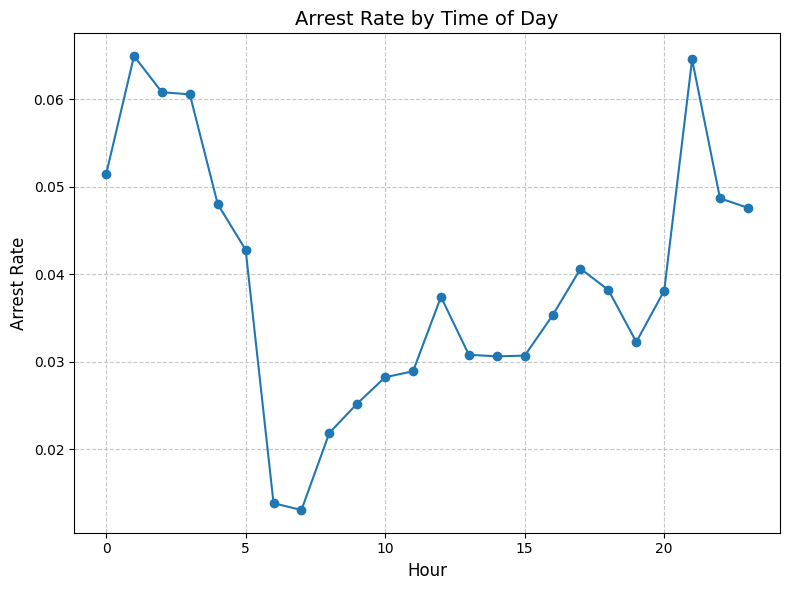

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'police.csv'  # Ganti dengan path file Anda
data = pd.read_csv(file_path)

# Step 1: Extract the hour from the stop_time column
data['stop_time'] = pd.to_datetime(data['stop_time'], format='%H:%M', errors='coerce')
data['hour'] = data['stop_time'].dt.hour

# Step 2: Calculate arrest rate by hour
arrest_rate_by_hour = data.groupby('hour')['is_arrested'].mean()

# Step 3: Plot the data
plt.figure(figsize=(8, 6))
plt.plot(arrest_rate_by_hour.index, arrest_rate_by_hour.values, marker='o')
plt.title('Arrest Rate by Time of Day', fontsize=14)
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Arrest Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Dari grafik **Arrest Rate by Time of Day**, kita bisa melihat pola penangkapan berdasarkan waktu. Penangkapan tertinggi terjadi di awal hari sekitar pukul **1-2 dini hari**, dengan tingkat penangkapan mencapai lebih dari **6%**. Setelah itu, ada penurunan drastis di pagi hari hingga sekitar pukul **5-6 pagi**, di mana tingkat penangkapan menjadi sangat rendah, bahkan di bawah **1%**.

Namun, saat hari berlanjut, tingkat penangkapan secara bertahap meningkat kembali, terutama setelah pukul **12 siang** hingga malam hari, dengan puncak lainnya sekitar pukul **8-9 malam**.

Jadi, waktu dengan aktivitas penangkapan tertinggi terjadi pada dini hari dan malam hari, sedangkan aktivitas ini sangat rendah di pagi hari. Pola ini mungkin bisa memberikan wawasan bagi pihak berwenang untuk merencanakan strategi patroli atau operasi penegakan hukum yang lebih efektif sesuai dengan waktu-waktu tertentu.

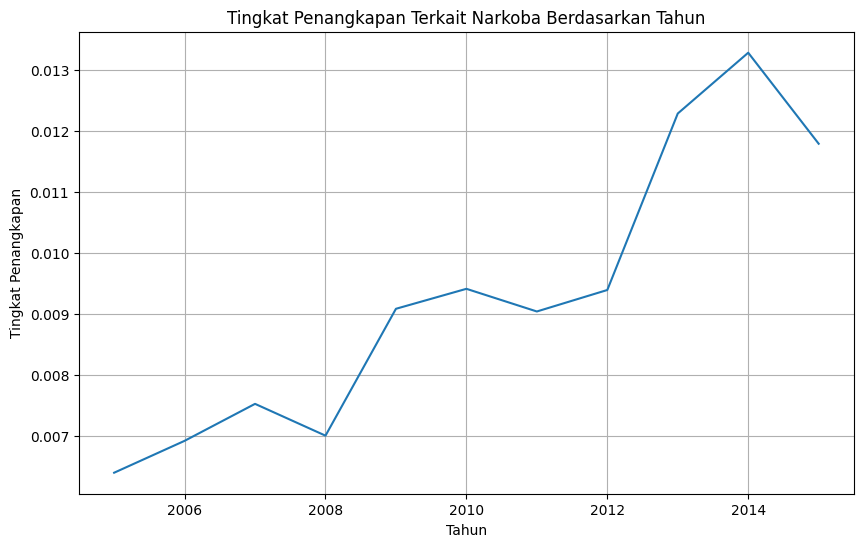

In [35]:
# Ubah kolom 'stop_date' menjadi format datetime untuk mengambil tahun
data['stop_datetime'] = pd.to_datetime(data['stop_date'], format='%Y-%m-%d', errors='coerce')

# Filter data untuk penangkapan yang berkaitan dengan narkoba
penangkapan_narkoba = data[data['drugs_related_stop'] == True]

# Kelompokkan data berdasarkan tahun dan hitung tingkat penangkapan narkoba
penangkapan_per_tahun = penangkapan_narkoba.groupby(penangkapan_narkoba['stop_datetime'].dt.year).size()
total_per_tahun = data.groupby(data['stop_datetime'].dt.year).size()
tingkat_penangkapan_narkoba = penangkapan_per_tahun / total_per_tahun

# Buat grafik
plt.figure(figsize=(10, 6))
plt.plot(tingkat_penangkapan_narkoba.index, tingkat_penangkapan_narkoba.values)
plt.title('Tingkat Penangkapan Terkait Narkoba Berdasarkan Tahun')
plt.xlabel('Tahun')
plt.ylabel('Tingkat Penangkapan')
plt.grid(True)
plt.show()

Dari grafik **Tingkat Penangkapan Terkait Narkoba Berdasarkan Tahun**, terlihat bahwa tingkat penangkapan mengalami fluktuasi dari tahun ke tahun. Di awal periode, sekitar tahun **2006**, tingkat penangkapan masih relatif rendah, yaitu di bawah **0.007**. Namun, terjadi peningkatan secara bertahap hingga mencapai puncaknya pada tahun **2013** dengan tingkat penangkapan tertinggi sekitar **0.013**.

Setelah itu, di tahun **2014**, terlihat adanya sedikit penurunan pada tingkat penangkapan dibandingkan dengan tahun sebelumnya. 

grafik time series diatas menunjukkan bahwa ada peningkatan signifikan dalam tingkat penangkapan kasus terkait narkoba selama beberapa tahun, meskipun ada sedikit penurunan di akhir periode. Hal ini bisa menjadi indikator bahwa upaya penegakan hukum semakin intensif, namun tetap diperlukan evaluasi untuk mempertahankan efektivitasnya.

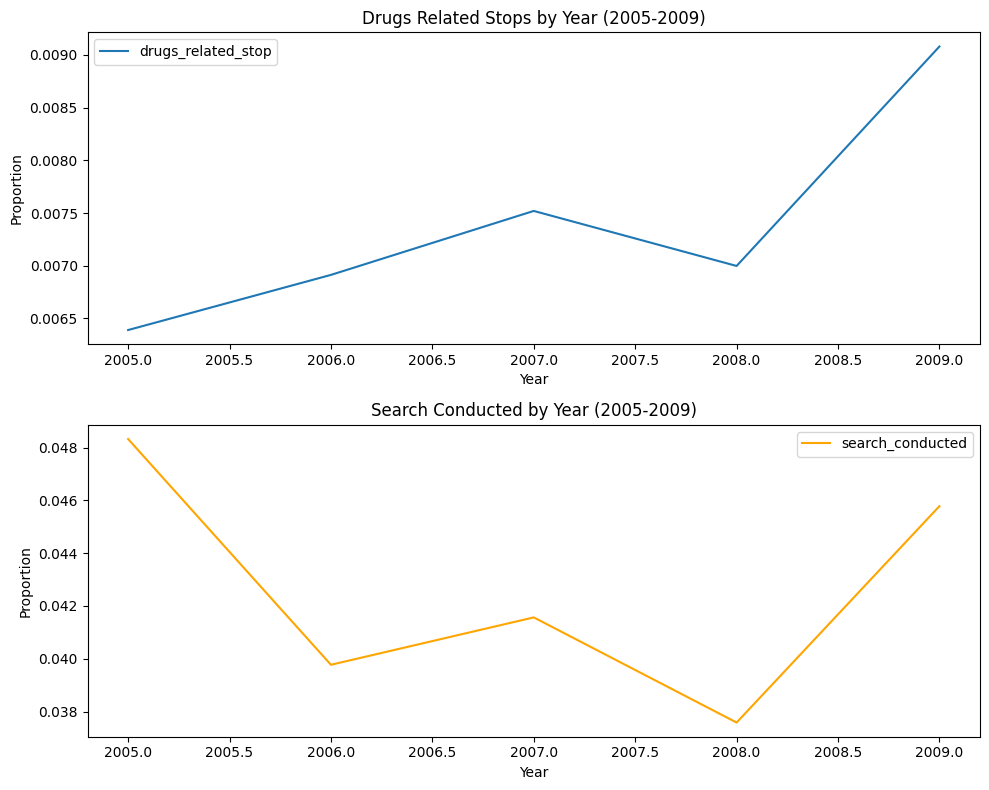

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'police.csv'  # Ganti dengan path file Anda
data = pd.read_csv(file_path)

# Convert 'stop_date' to datetime format
data['stop_date'] = pd.to_datetime(data['stop_date'], errors='coerce')

# Tambahkan kolom tahun dari 'stop_date'
data['year'] = data['stop_date'].dt.year

# Filter data untuk rentang tahun 2005 - 2009
filtered_data = data[(data['year'] >= 2005) & (data['year'] <= 2009)]

# Agregasi data untuk pemberhentian terkait narkoba dan pencarian yang dilakukan
drugs_related_stop = filtered_data.groupby('year')['drugs_related_stop'].mean()
search_conducted = filtered_data.groupby('year')['search_conducted'].mean()

# Plot grafik
plt.figure(figsize=(10, 8))

# Subplot 1: Drugs related stop
plt.subplot(2, 1, 1)
drugs_related_stop.plot(label='drugs_related_stop', legend=True)
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.title('Drugs Related Stops by Year (2005-2009)')

# Subplot 2: Search conducted
plt.subplot(2, 1, 2)
search_conducted.plot(color='orange', label='search_conducted', legend=True)
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.title('Search Conducted by Year (2005-2009)')

# Show plot
plt.tight_layout()
plt.show()

Dari grafik pertama tentang **Drugs Related Stops by Year (2005-2009)**, terlihat bahwa pemberhentian kendaraan yang terkait dengan kasus narkoba mengalami peningkatan secara bertahap dari tahun **2005** hingga **2007**, kemudian menurun di tahun **2008**, dan kembali naik tajam pada tahun **2009**. Hal ini menunjukkan adanya pola fluktuasi dalam kasus pemberhentian terkait narkoba selama periode tersebut.

Pada grafik kedua tentang **Search Conducted by Year (2005-2009)**, proporsi pencarian yang dilakukan justru menunjukkan tren menurun secara signifikan dari tahun **2005** ke **2006**. Setelah itu, trennya relatif stabil hingga tahun **2008**, dengan sedikit kenaikan kembali pada tahun **2009**. 

Jadi teman-teman, meskipun pencarian yang dilakukan cenderung menurun di sebagian besar periode, pemberhentian kendaraan terkait narkoba meningkat, terutama pada tahun **2009**. Ini bisa menunjukkan bahwa meskipun intensitas pencarian menurun, fokus atau keberhasilan dalam mengidentifikasi kasus terkait narkoba meningkat pada akhir periode.

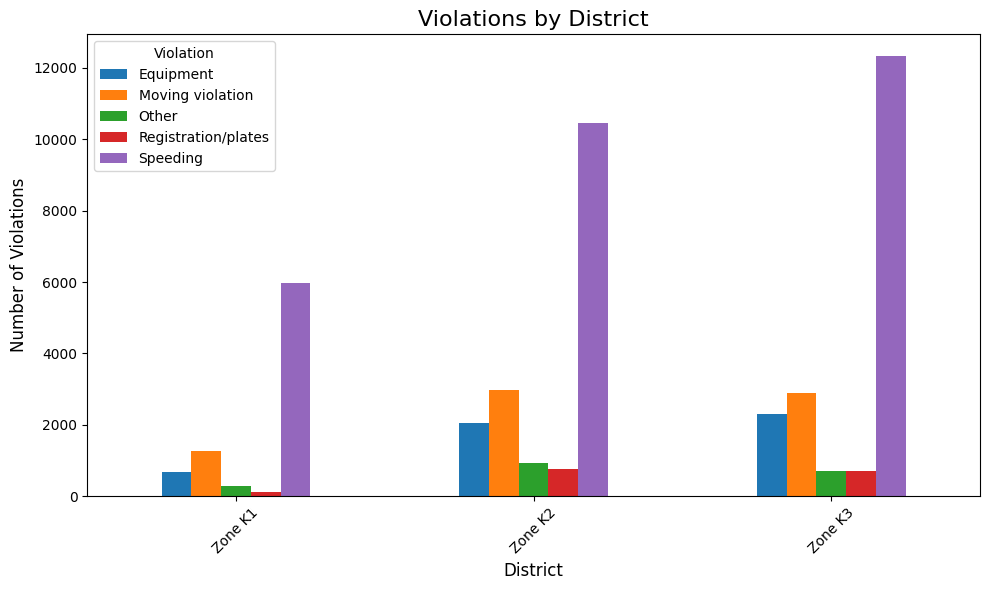

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'police.csv'  # Ganti dengan path file Anda
data = pd.read_csv(file_path)

# Pastikan kolom 'district' dan 'violation' ada dalam dataset
if 'district' in data.columns and 'violation' in data.columns:
    # Filter untuk menghapus kategori 'Seat belt'
    filtered_data = data[data['violation'] != 'Seat belt']
    
    # Pilih hanya 3 zona pertama
    first_three_zones = ['Zone K1', 'Zone K2', 'Zone K3']  # Ganti nama zona sesuai dataset
    filtered_data = filtered_data[filtered_data['district'].isin(first_three_zones)]
    
    # Hitung jumlah pelanggaran berdasarkan 'district' dan 'violation'
    violation_count = filtered_data.groupby(['district', 'violation']).size().unstack(fill_value=0)

    # Plot bar chart
    violation_count.plot(kind='bar', stacked=False, figsize=(10, 6))

    # Tambahkan judul dan label
    plt.title('Violations by District', fontsize=16)
    plt.xlabel('District', fontsize=12)
    plt.ylabel('Number of Violations', fontsize=12)

    # Tampilkan legenda dan rotasi label x
    plt.legend(title='Violation', fontsize=10)
    plt.xticks(rotation=45)

    # Tampilkan plot
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'district' atau 'violation' tidak ditemukan dalam dataset.")

Dari grafik **Violations by District**, terlihat bahwa pelanggaran jenis **Speeding** mendominasi di semua zona (K1, K2, dan K3). Jumlah pelanggaran ini jauh lebih tinggi dibandingkan jenis pelanggaran lainnya seperti **Moving violation**, **Equipment**, **Registration/plates**, dan **Other**.

Di Zona **K1**, pelanggaran jenis **Moving violation** dan **Equipment** juga cukup signifikan dibandingkan pelanggaran lainnya (selain **Speeding**). Di Zona **K2**, pola serupa terlihat, tetapi jumlah pelanggaran untuk semua kategori, termasuk **Speeding**, lebih tinggi dibandingkan Zona **K1**. Zona **K3** memiliki jumlah pelanggaran yang sangat mirip dengan Zona **K2**, tetapi sedikit lebih tinggi untuk jenis pelanggaran tertentu.

Kita bisa tarik kesimpulannya, pelanggaran **Speeding** menjadi perhatian utama di semua zona, dengan Zona **K2** dan **K3** memiliki jumlah pelanggaran keseluruhan yang lebih banyak dibandingkan dengan Zona **K1**. Hal ini menunjukkan bahwa mungkin perlu ada penanganan khusus di Zona **K2** dan **K3** untuk mengurangi pelanggaran, terutama terkait dengan kecepatan.

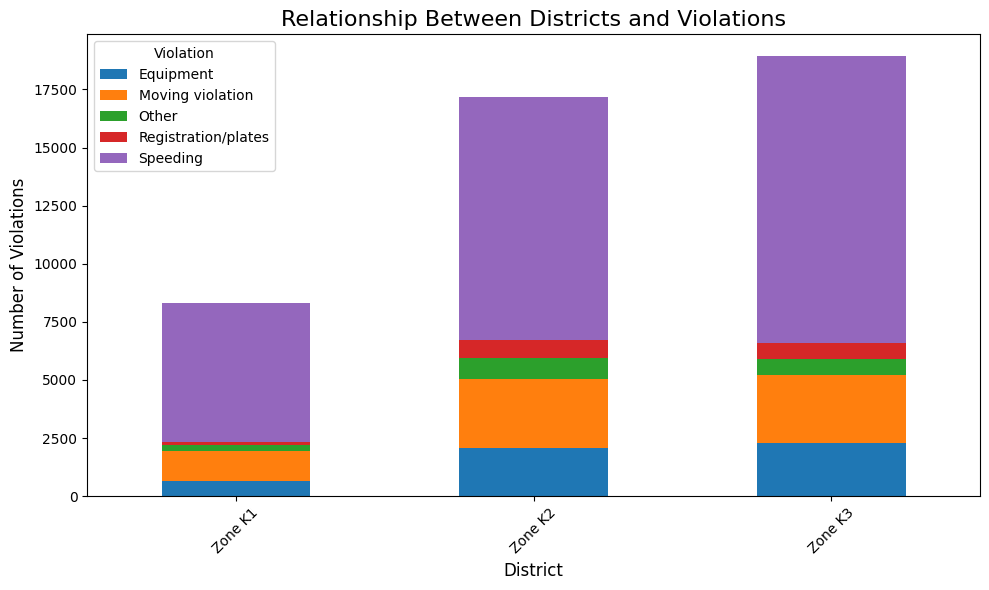

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'police.csv'  # Ganti dengan path file Anda
data = pd.read_csv(file_path)

# Pastikan kolom 'district' dan 'violation' ada dalam dataset
if 'district' in data.columns and 'violation' in data.columns:
    # Filter untuk menghapus kategori 'Seat belt'
    filtered_data = data[data['violation'] != 'Seat belt']
    
    # Pilih hanya 3 distrik pertama
    first_three_zones = ['Zone K1', 'Zone K2', 'Zone K3']  # Sesuaikan nama distrik Anda
    filtered_data = filtered_data[filtered_data['district'].isin(first_three_zones)]
    
    # Hitung jumlah pelanggaran berdasarkan 'district' dan 'violation'
    violation_count = filtered_data.groupby(['district', 'violation']).size().unstack(fill_value=0)

    # Plot grafik batang tumpuk
    violation_count.plot(kind='bar', stacked=True, figsize=(10, 6))

    # Tambahkan judul dan label
    plt.title('Relationship Between Districts and Violations', fontsize=16)
    plt.xlabel('District', fontsize=12)
    plt.ylabel('Number of Violations', fontsize=12)

    # Tampilkan legenda dan rotasi label x
    plt.legend(title='Violation', fontsize=10)
    plt.xticks(rotation=45)

    # Tampilkan plot
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'district' atau 'violation' tidak ditemukan dalam dataset.")

Dari grafik **Relationship Between Districts and Violations**, kita bisa lihat bahwa pelanggaran **Speeding** mendominasi di semua zona (K1, K2, dan K3). Jumlah pelanggaran ini sangat jauh di atas pelanggaran jenis lainnya seperti **Equipment**, **Moving violation**, **Other**, dan **Registration/plates**.

Zona **K2** dan **K3** memiliki jumlah pelanggaran yang hampir sama, tetapi keduanya lebih tinggi dibandingkan dengan Zona **K1**. Zona **K1** terlihat memiliki jumlah pelanggaran yang lebih rendah secara keseluruhan dibandingkan dua zona lainnya.

Kesimpulannya, pelanggaran **Speeding** adalah yang paling banyak terjadi di semua zona. Zona **K2** dan **K3** membutuhkan perhatian lebih besar karena jumlah pelanggaran yang lebih tinggi dibandingkan dengan Zona **K1**. Ini mungkin bisa menjadi dasar untuk evaluasi kebijakan penegakan hukum di masing-masing zona.